In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
raw_df = pd.read_csv(r"C:\Users\dsk2\Downloads\healthcare_risk_dataset.csv")

In [5]:
df = raw_df.copy()

In [32]:
print("no of rows and columns =",df.shape)

no of rows and columns = (5000, 51)


In [6]:
df.head()

,Patient_ID,Age,Gender,Marital_Status,Education,City,City_Tier,Occupation,Blood_Group,Insurance_Type,...,Hospitalized_Last_Year,Last_Visit_Date,Reason_Last_Visit,Avg_Hospital_Cost_INR,Anxiety_Score,Depression_Score,Health_Risk_Score,Risk_Category,Readmission_Risk,Preventive_Care_Recommended
0,PAT00001,51,Male,Divorced,10th Pass,Dindigul,Tier 3,Business Owner,O+,NaN,...,0,2026-02-15,Respiratory Issue,34075,6,2,37.5,Moderate,0,Diabetes Screening | Lipid Profile Follow-up |...
1,PAT00002,63,Female,Single,No Formal,Chennai,Tier 1,Retired,B+,NaN,...,1,2026-03-25,Respiratory Issue,46766,10,8,84.2,Critical,1,Diabetes Screening | BP Management | Weight Ma...
2,PAT00003,40,Female,Married,12th Pass,Mumbai,Tier 1,Retired,A+,Government Scheme,...,1,2025-02-05,Respiratory Issue,42722,6,5,62.0,High,1,Diabetes Screening | BP Management | Weight Ma...
3,PAT00004,56,Male,Single,Graduate,Jodhpur,Tier 3,Business Owner,O+,NaN,...,1,2025-09-01,Respiratory Issue,23354,6,6,44.6,Moderate,1,Diabetes Screening | BP Management | Weight Ma...
4,PAT00005,38,Male,Married,Graduate,Madurai,Tier 2,Moderate (Teacher/Retail),O+,NaN,...,0,2025-01-26,Diabetes Complication,4117,1,0,5.4,Low,0,Diabetes Screening | Weight Management


In [8]:
print("duplicates ",df.duplicated().sum())

duplicates  0


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Patient_ID                   5000 non-null   object 
 1   Age                          5000 non-null   int64  
 2   Gender                       5000 non-null   object 
 3   Marital_Status               5000 non-null   object 
 4   Education                    5000 non-null   object 
 5   City                         5000 non-null   object 
 6   City_Tier                    5000 non-null   object 
 7   Occupation                   5000 non-null   object 
 8   Blood_Group                  5000 non-null   object 
 9   Insurance_Type               3513 non-null   object 
 10  Diet_Type                    5000 non-null   object 
 11  Smoking_Status               5000 non-null   object 
 12  Alcohol_Consumption          5000 non-null   object 
 13  Exercise_Frequency

In [72]:
print("null values\n" , df.isna().sum())

null values
 Patient_ID                     0
Age                            0
Gender                         0
Marital_Status                 0
Education                      0
City                           0
City_Tier                      0
Occupation                     0
Blood_Group                    0
Insurance_Type                 0
Diet_Type                      0
Smoking_Status                 0
Alcohol_Consumption            0
Exercise_Frequency             0
Stress_Level                   0
Sleep_Hours                    0
Water_Intake_Liters            0
BMI                            0
Blood_Pressure                 0
Systolic_BP                    0
Diastolic_BP                   0
Resting_Heart_Rate             0
Blood_Glucose_Fasting          0
HbA1c                          0
Cholesterol_Total              0
HDL_Cholesterol                0
LDL_Cholesterol                0
Triglycerides                  0
Hemoglobin                     0
Creatinine                    

In [19]:
null_df = pd.DataFrame({
    'Null Count'  : df.isnull().sum(),
    'Percentage %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_df[null_df['Null Count'] > 0])

                      Null Count  Percentage %
Insurance_Type              1487         29.74
Exercise_Frequency          1339         26.78
Chronic_Condition           2434         48.68
Medication_Adherence        1864         37.28


In [20]:
### in this data there is no null but none represents like this.. so need to fill with mean median or mode.
# treating null values
df["Insurance_Type"] = df.Insurance_Type.fillna("No insurance")
df['Exercise_Frequency'] = df.Exercise_Frequency.fillna('Not Active')
df['Chronic_Condition'] = df.Chronic_Condition.fillna('None')
df['Medication_Adherence'] = df.Medication_Adherence.fillna('Not on Medication')

In [23]:
print("treated null values\n",df.isna().sum())

treated null values
 Patient_ID                     0
Age                            0
Gender                         0
Marital_Status                 0
Education                      0
City                           0
City_Tier                      0
Occupation                     0
Blood_Group                    0
Insurance_Type                 0
Diet_Type                      0
Smoking_Status                 0
Alcohol_Consumption            0
Exercise_Frequency             0
Stress_Level                   0
Sleep_Hours                    0
Water_Intake_Liters            0
BMI                            0
Blood_Pressure                 0
Systolic_BP                    0
Diastolic_BP                   0
Resting_Heart_Rate             0
Blood_Glucose_Fasting          0
HbA1c                          0
Cholesterol_Total              0
HDL_Cholesterol                0
LDL_Cholesterol                0
Triglycerides                  0
Hemoglobin                     0
Creatinine            

In [35]:
df.describe()

,Age,Sleep_Hours,Water_Intake_Liters,BMI,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,Blood_Glucose_Fasting,HbA1c,Cholesterol_Total,...,Family_History_Cancer,On_Medication,No_of_Medications,Visits_Last_Year,Hospitalized_Last_Year,Avg_Hospital_Cost_INR,Anxiety_Score,Depression_Score,Health_Risk_Score,Readmission_Risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,41.530200,6.635620,2.098500,27.312280,130.402200,84.313600,74.639200,114.250400,6.310900,207.271800,...,0.178200,0.627200,0.970400,4.945600,0.530000,26128.928800,4.814400,3.983400,41.914120,0.332200
std,13.421517,1.095073,0.511461,6.134852,17.645835,13.836587,10.179202,37.986033,1.410156,44.459114,...,0.382719,0.483598,1.353769,2.655419,0.499149,13416.786343,2.590385,2.409624,21.883564,0.471049
min,18.000000,3.000000,0.500000,14.000000,89.000000,55.000000,45.000000,60.000000,4.000000,100.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,500.000000,0.000000,0.000000,5.000000,0.000000
25%,31.000000,5.900000,1.800000,22.600000,117.000000,74.000000,68.000000,89.000000,5.300000,175.000000,...,0.000000,0.000000,0.000000,3.000000,0.000000,16448.750000,3.000000,2.000000,24.200000,0.000000
50%,40.000000,6.600000,2.100000,26.600000,128.000000,83.000000,75.000000,103.000000,5.900000,201.000000,...,0.000000,1.000000,0.000000,5.000000,1.000000,25707.000000,5.000000,4.000000,41.200000,0.000000
75%,52.000000,7.400000,2.400000,31.200000,141.000000,93.000000,81.000000,128.000000,7.000000,235.000000,...,0.000000,1.000000,2.000000,7.000000,1.000000,35094.000000,7.000000,6.000000,57.600000,1.000000
max,85.000000,10.000000,4.000000,52.000000,214.000000,130.000000,113.000000,330.000000,12.900000,387.000000,...,1.000000,1.000000,5.000000,19.000000,1.000000,69468.000000,10.000000,10.000000,97.900000,1.000000


In [27]:
numerical_columns = df.select_dtypes(include = 'number')
categorical_columns = df.select_dtypes(exclude = 'number')

In [38]:
for i in categorical_columns:
    print(df[i].value_counts())

Patient_ID
PAT00001    1
PAT03331    1
PAT03338    1
PAT03337    1
PAT03336    1
           ..
PAT01667    1
PAT01666    1
PAT01665    1
PAT01664    1
PAT05000    1
Name: count, Length: 5000, dtype: int64
Gender
Male      2672
Female    2245
Other       83
Name: count, dtype: int64
Marital_Status
Married     3074
Single      1008
Divorced     525
Widowed      393
Name: count, dtype: int64
Education
Graduate         2148
Post Graduate     949
12th Pass         877
10th Pass         690
No Formal         336
Name: count, dtype: int64
City
Bangalore     224
Coimbatore    221
Indore        218
Erode         214
Dindigul      213
Hyderabad     213
Kochi         211
Tiruppur      207
Udaipur       206
Jaipur        205
Vellore       205
Salem         204
Nagpur        202
Mysuru        200
Jodhpur       200
Delhi         199
Trichy        198
Chennai       197
Lucknow       194
Madurai       192
Thanjavur     189
Surat         180
Kolkata       180
Pune          166
Mumbai        162
Name: c

In [43]:
df.plot(kind = "box")

<Axes: >

In [40]:
#outlaiers
for i in numerical_columns:
    q1 = df[i].quantile(.25)
    q3 = df[i].quantile(.75)
    IQR = q3 - q1
    lb = q1 - 1.5 * IQR
    ub = q3 + 1.5 * IQR
    outliers = df[(df[i]< lb) | (df[i]>ub)]

    print(f"\ncolumn : {i}")
    print(f"Q1 : {q1}")
    print(f"Q3 : {q3}")
    print(f"IQR : {IQR}")
    print("oulaiers count :",len(outliers))


column : Age
Q1 : 31.0
Q3 : 52.0
IQR : 21.0
oulaiers count : 3

column : Sleep_Hours
Q1 : 5.9
Q3 : 7.4
IQR : 1.5
oulaiers count : 44

column : Water_Intake_Liters
Q1 : 1.8
Q3 : 2.4
IQR : 0.5999999999999999
oulaiers count : 96

column : BMI
Q1 : 22.6
Q3 : 31.2
IQR : 8.599999999999998
oulaiers count : 45

column : Systolic_BP
Q1 : 117.0
Q3 : 141.0
IQR : 24.0
oulaiers count : 68

column : Diastolic_BP
Q1 : 74.0
Q3 : 93.0
IQR : 19.0
oulaiers count : 43

column : Resting_Heart_Rate
Q1 : 68.0
Q3 : 81.0
IQR : 13.0
oulaiers count : 58

column : Blood_Glucose_Fasting
Q1 : 89.0
Q3 : 128.0
IQR : 39.0
oulaiers count : 297

column : HbA1c
Q1 : 5.3
Q3 : 7.0
IQR : 1.7000000000000002
oulaiers count : 199

column : Cholesterol_Total
Q1 : 175.0
Q3 : 235.0
IQR : 60.0
oulaiers count : 58

column : HDL_Cholesterol
Q1 : 43.0
Q3 : 57.0
IQR : 14.0
oulaiers count : 43

column : LDL_Cholesterol
Q1 : 110.0
Q3 : 158.0
IQR : 48.0
oulaiers count : 34

column : Triglycerides
Q1 : 142.0
Q3 : 228.0
IQR : 86.0
oulaier

In [44]:
#treating outliers in mediacl reference extreme values are important
# so we use mediacal capping based on medical reference ranges

medical_caps = {
    'BMI'                   : (14.0,  50.0),
    'Systolic_BP'           : (80.0,  200.0),
    'Diastolic_BP'          : (50.0,  130.0),
    'Blood_Glucose_Fasting' : (60.0,  400.0),
    'HbA1c'                 : (4.0,   14.0),
    'Cholesterol_Total'     : (100.0, 400.0),
    'HDL_Cholesterol'       : (20.0,  100.0),
    'LDL_Cholesterol'       : (40.0,  300.0),
    'Triglycerides'         : (50.0,  600.0),
    'Hemoglobin'            : (6.0,   20.0),
    'Creatinine'            : (0.3,   10.0),
    'Vitamin_D'             : (4.0,   80.0),
    'TSH'                   : (0.1,   15.0),
    'Resting_Heart_Rate'    : (40.0,  130.0),
    'Sleep_Hours'           : (3.0,   12.0),
    'Age'                   : (18.0,  90.0),
    'Avg_Hospital_Cost_INR' : (500.0, 200000.0),
}

print("Capping outliers to medical reference ranges...")
print(f"\n{'Column':<30} {'Before Min':>10} {'Before Max':>10} {'After Min':>10} {'After Max':>10}")
print("-" * 72)

for col, (low, high) in medical_caps.items():
    before_min = df[col].min()
    before_max = df[col].max()
    df[col]    = df[col].clip(lower=low, upper=high)
    print(f"{col:<30} {before_min:>10.1f} {before_max:>10.1f} {df[col].min():>10.1f} {df[col].max():>10.1f}")

print("\n✅ All outliers capped to medical reference ranges")

Capping outliers to medical reference ranges...

Column                         Before Min Before Max  After Min  After Max
------------------------------------------------------------------------
BMI                                  14.0       52.0       14.0       50.0
Systolic_BP                          89.0      214.0       89.0      200.0
Diastolic_BP                         55.0      130.0       55.0      130.0
Blood_Glucose_Fasting                60.0      330.0       60.0      330.0
HbA1c                                 4.0       12.9        4.0       12.9
Cholesterol_Total                   100.0      387.0      100.0      387.0
HDL_Cholesterol                      20.0       91.0       20.0       91.0
LDL_Cholesterol                      40.0      260.0       40.0      260.0
Triglycerides                        50.0      425.0       50.0      425.0
Hemoglobin                            7.0       18.5        7.0       18.5
Creatinine                            0.4        3.0 

In [49]:
# Risk Category count
print("Risk Category Distribution:")
print(df['Risk_Category'].value_counts())

# Readmission rate by risk category
print("\nReadmission Rate % by Risk Category:")
print(df.groupby('Risk_Category')['Readmission_Risk'].mean().round(3) * 100)

# Avg hospital cost by chronic condition
print("\nAvg Hospital Cost by Chronic Condition:")
print(df.groupby('Chronic_Condition')['Avg_Hospital_Cost_INR'].mean().round(0).sort_values(ascending=False))

# Avg risk score by city tier
print("\nAvg Risk Score by City Tier:")
print(df.groupby('City_Tier')['Health_Risk_Score'].mean().round(2))


Risk Category Distribution:
Risk_Category
Moderate    1730
Low         1531
High        1260
Critical     479
Name: count, dtype: int64

Readmission Rate % by Risk Category:
Risk_Category
Critical    63.5
High        48.4
Low         12.5
Moderate    32.1
Name: Readmission_Risk, dtype: float64

Avg Hospital Cost by Chronic Condition:
Chronic_Condition
Both             35509.0
Heart Disease    34442.0
Asthma           31655.0
Hypertension     30700.0
Diabetes         29661.0
None             20643.0
Name: Avg_Hospital_Cost_INR, dtype: float64

Avg Risk Score by City Tier:
City_Tier
Tier 1    41.92
Tier 2    42.10
Tier 3    41.68
Name: Health_Risk_Score, dtype: float64


,Patient_ID,Age,Gender,Marital_Status,Education,City,City_Tier,Occupation,Blood_Group,Insurance_Type,...,Last_Visit_Date,Reason_Last_Visit,Avg_Hospital_Cost_INR,Anxiety_Score,Depression_Score,Health_Risk_Score,Risk_Category,Readmission_Risk,Preventive_Care_Recommended,Age_Group
0,0,51,1,0,0,19,2,1,6,1,...,566,8,34075,6,2,37.5,3,0,99,51-60
1,1,63,0,2,3,1,0,4,4,1,...,608,8,46766,10,8,84.2,0,1,43,60+
2,1112,40,0,1,1,6,0,4,0,0,...,150,8,42722,6,5,62.0,1,1,31,31-40
3,2223,56,1,2,2,24,2,1,6,1,...,381,8,23354,6,6,44.6,3,1,37,51-60
4,3334,38,1,1,2,5,1,3,6,1,...,139,2,4117,1,0,5.4,2,0,121,31-40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4440,61,0,1,2,4,1,5,0,2,...,492,2,32536,6,2,54.8,1,0,49,60+
4996,4441,23,1,1,2,13,2,0,0,0,...,318,8,13162,0,4,28.4,2,0,192,18-30
4997,4442,51,0,2,2,22,1,2,6,2,...,48,9,43613,4,2,44.9,3,0,171,51-60
4998,4443,52,1,0,2,3,0,0,5,2,...,236,9,26083,10,6,50.7,1,1,298,51-60


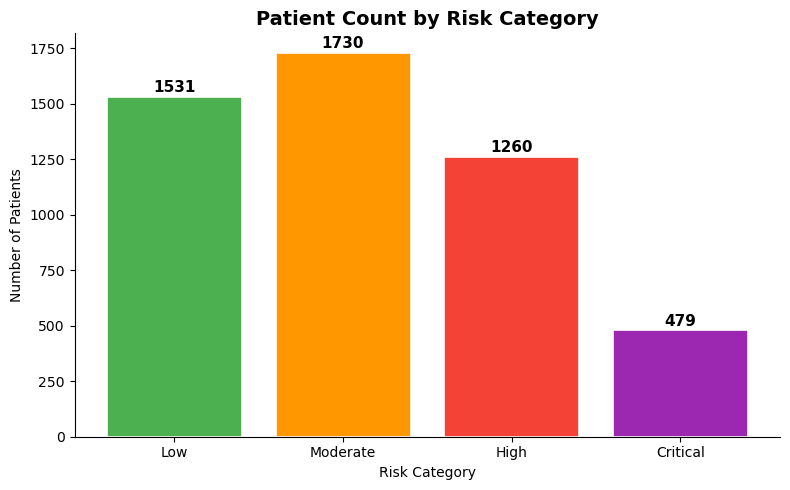

In [52]:
#risk category distribution

RISK_COLORS = {'Low':'#4CAF50','Moderate':'#FF9800','High':'#F44336','Critical':'#9C27B0'}

risk_counts = df['Risk_Category'].value_counts().reindex(['Low','Moderate','High','Critical'])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(risk_counts.index, risk_counts.values,
              color=[RISK_COLORS[r] for r in risk_counts.index],
              edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, risk_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', fontweight='bold', fontsize=11)

ax.set_title('Patient Count by Risk Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Category')
ax.set_ylabel('Number of Patients')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('01_risk_distribution.png', dpi=150)
plt.show()

C:\Users\dsk2\AppData\Local\Temp\ipykernel_7660\826781509.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk = df.groupby('Age_Group')['Health_Risk_Score'].mean()


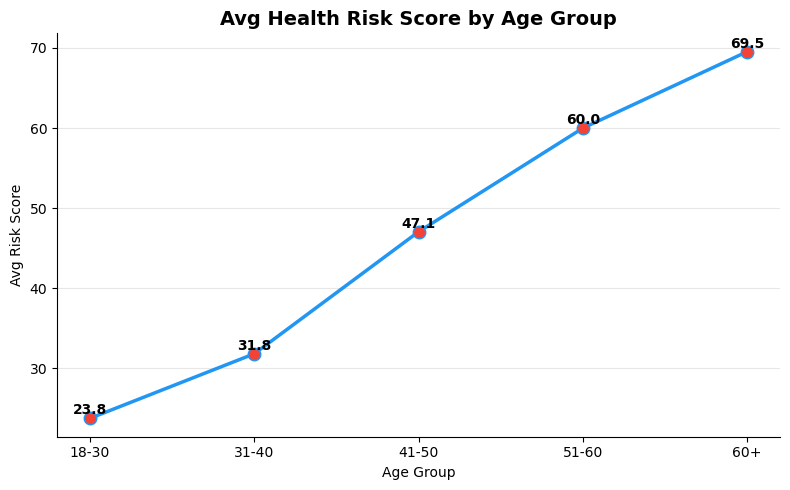

In [53]:
#risk score by age group

df['Age_Group'] = pd.cut(df['Age'],
    bins=[17, 30, 40, 50, 60, 85],
    labels=['18-30','31-40','41-50','51-60','60+'])

age_risk = df.groupby('Age_Group')['Health_Risk_Score'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(age_risk.index.astype(str), age_risk.values,
        marker='o', color='#2196F3', linewidth=2.5,
        markersize=9, markerfacecolor='#F44336')

for x, y in enumerate(age_risk.values):
    ax.text(x, y + 0.5, f'{y:.1f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Avg Health Risk Score by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Avg Risk Score')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('02_risk_by_age.png', dpi=150)
plt.show()

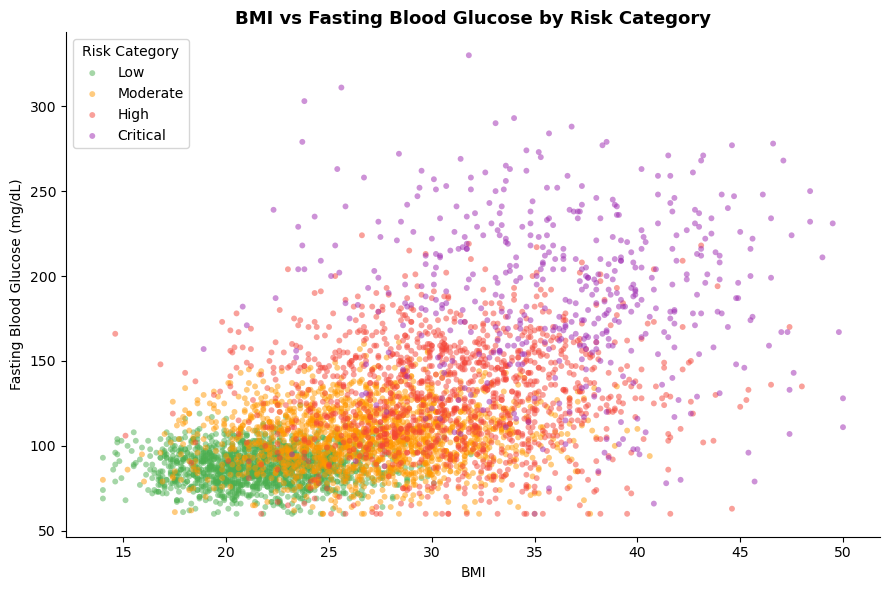

In [54]:
#Bmi vs blood glucose scatter

fig, ax = plt.subplots(figsize=(9, 6))

for rc, color in RISK_COLORS.items():
    subset = df[df['Risk_Category'] == rc]
    ax.scatter(subset['BMI'], subset['Blood_Glucose_Fasting'],
               c=color, label=rc, alpha=0.5, s=18, edgecolors='none')

ax.set_title('BMI vs Fasting Blood Glucose by Risk Category', fontsize=13, fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Fasting Blood Glucose (mg/dL)')
ax.legend(title='Risk Category')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('03_bmi_vs_glucose.png', dpi=150)
plt.show()

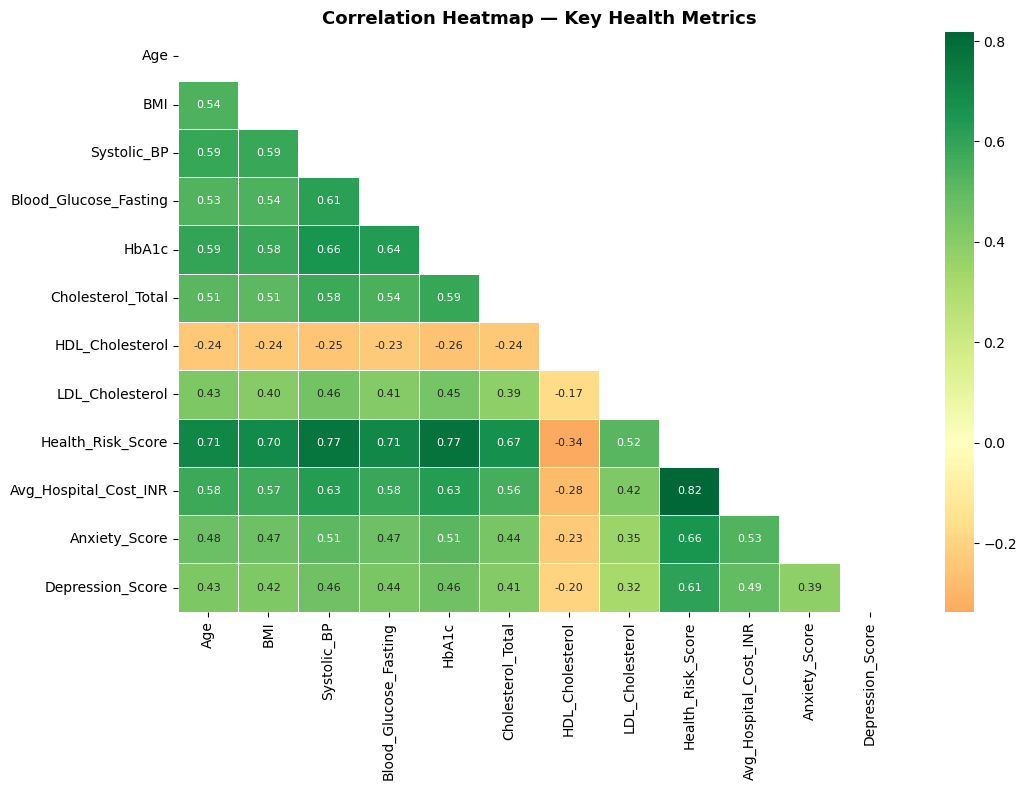

In [57]:
#correlation heatmap

num_cols = ['Age','BMI','Systolic_BP','Blood_Glucose_Fasting','HbA1c',
            'Cholesterol_Total','HDL_Cholesterol','LDL_Cholesterol',
            'Health_Risk_Score','Avg_Hospital_Cost_INR',
            'Anxiety_Score','Depression_Score']

fig, ax = plt.subplots(figsize=(11, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})

ax.set_title('Correlation Heatmap — Key Health Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150)
plt.show()

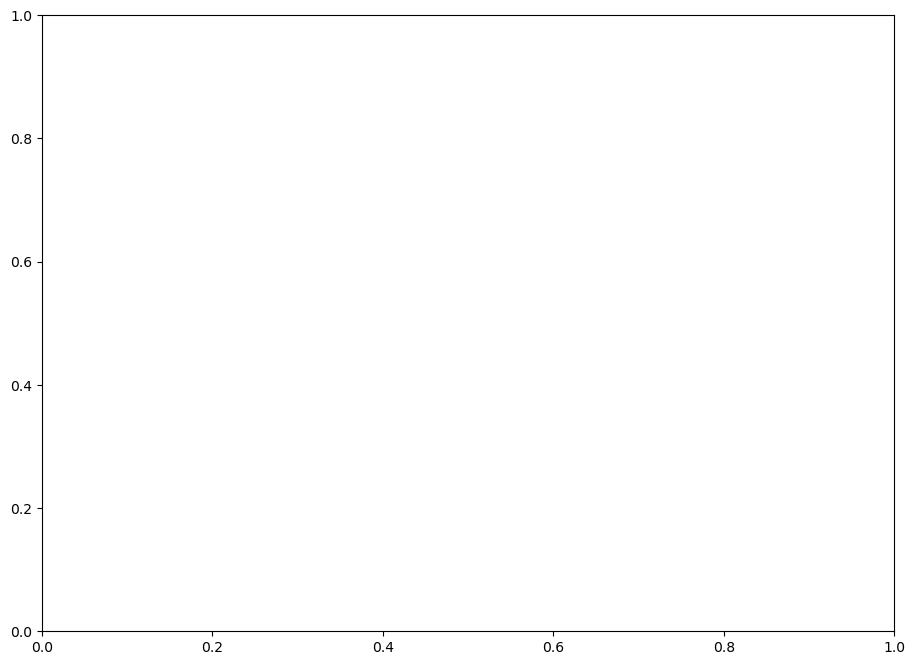

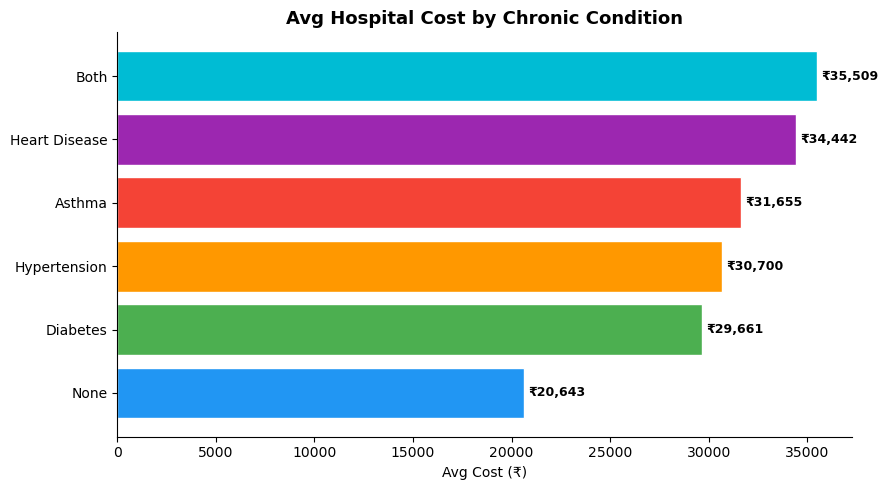

In [59]:
#hospital cost by chronic condition

avg_cost = df.groupby('Chronic_Condition')['Avg_Hospital_Cost_INR'].mean().sort_values(ascending=True)
COLORS   = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(avg_cost.index, avg_cost.values,
               color=COLORS[:len(avg_cost)], edgecolor='white')

for bar, val in zip(bars, avg_cost.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Avg Hospital Cost by Chronic Condition', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Cost (₹)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('05_cost_by_chronic.png', dpi=150)
plt.show()